Følger denne guide: https://www.youtube.com/watch?v=Wo5dMEP_BbI&list=PLQVvvaa0QuDcjD5BAw2DxE6OF2tius3V3


### Neuron first iteration (simple 1 layer)

In [18]:
inputs = [1,2,3, 2.5]

weights1 = [0.2, 0.8, -.5, 1.]
weights2= [.15, -.91, .26, -.5]
weights3 = [-.26, -.27, .17, -.87]

bias1 = 2.
bias2 = 3.
bias3 = .5

output = [inputs[0] * weights1[0] + inputs[1] * weights1[1] + inputs[2] * weights1[2] + inputs[3] * weights1[3] + bias1, 
          inputs[0] * weights2[0] + inputs[1] * weights2[1] + inputs[2] * weights2[2] + inputs[3] * weights2[3] + bias2,
          inputs[0] * weights3[0] + inputs[1] * weights3[1] + inputs[2] * weights3[2] + inputs[3] * weights3[3] + bias3]
output

[4.8, 0.8599999999999999, -1.9649999999999999]

In [19]:
weights = [[0.2, 0.8, -.5, 1.],
           [.15, -.91, .26, -.5],
           [-.26, -.27, .17, -.87]]

bias = [2,3,.5]

layer_output = []
for neuron_weights, neuron_bias in zip(weights, bias):
    neuron_output = 0
    for n_input, weight in zip(inputs, neuron_weights):
        neuron_output += n_input * weight
    neuron_output += neuron_bias
    layer_output.append(neuron_output)
    
print(layer_output)

[4.8, 0.8599999999999999, -1.9649999999999999]


In [20]:
import numpy as np
import sympy as sp

In [21]:
inputs = [1,2,3,2.5]
weights = [[0.2, 0.8, -.5, 1.],
           [.15, -.91, .26, -.5],
           [-.26, -.27, .17, -.87]]


weight = np.matrix([[0.2, 0.8, -.5, 1.],[.5, -.91, .26, -.5],[-.26, -.27, .17, -.87]])
#weight2 = sp.Matrix([[0.2, 0.8, -.5, 1.],[.15, -.91, .26, -.5],[-.26, -.27, .17, -.87]])


bias = [2,3,.5]

output = np.dot(weight,inputs) + bias
output

AttributeError: 'list' object has no attribute 'astype'

### Two layer

In [ ]:
inputs = np.matrix([[1.,2.,3.,2.5], [2.,5.,-1.,2.],[-1.5,2.7,3.3,-.8]])

weight1 = np.matrix([[0.2, 0.8, -.5, 1.],[.5, -.91, .26, -.5],[-.26, -.27, .17, -.87]])
weight2 = np.matrix([[0.1, -.14, 0.5],[-.5, .12, -.33],[-.44, .73, -.13]])

bias1 = [2,3,.5]
bias2 = [-1,2,-.5]

layer1_outputs = np.dot(inputs, weight1.T) + bias1
layer2_outputs = np.dot(layer1_outputs, weight2.T) + bias2
display(layer1_outputs,layer2_outputs)


matrix([[ 4.8  ,  1.21 , -1.965],
        [ 8.9  , -1.81 , -3.28 ],
        [ 1.41 ,  1.051,  1.418]])

matrix([[-1.6719 ,  0.39365, -1.47325],
        [-1.4966 , -1.5848 , -5.3109 ],
        [-0.29714,  0.95318, -0.53751]])

In [ ]:
np.random.seed(0)

X = np.matrix([[1.,2.,3.,2.5], [2.,5.,-1.,2.],[-1.5,2.7,3.3,-.8]]) #Input layer

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)# randn is a gausian distrubtion that bounces from 0 (multiplies with 0.10 to keep the initialized wheigths around 0)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

layer1 = Layer_Dense(4, 5) # Input layer 4 and outputs 5
layer2 = Layer_Dense(5, 2) # Takes the 5 neurons outputs as inputs and outputs 2 neurons

layer1.forward(X)
#print(layer1.output)
layer2.forward(layer1.output)
#print(layer2.output)
display(layer1.output, layer2.output)

matrix([[ 0.10758131,  1.03983522,  0.24462411,  0.31821498,  0.18851053],
        [-0.08349796,  0.70846411,  0.00293357,  0.44701525,  0.36360538],
        [-0.50763245,  0.55688422,  0.07987797, -0.34889573,  0.04553042]])

matrix([[ 0.148296  , -0.08397602],
        [ 0.14100315, -0.01340469],
        [ 0.20124979, -0.07290616]])

# Activation functions

## ReLu

In [ ]:
import nnfs

In [ ]:
# Rectify linear activation function
inputs = [0,2,-1,3.3,-2.7,1.1,2.2,-100]
output = []

for i in inputs:
    if i > 0:
        output.append(i)
    elif i <= 0:
        output.append(0)
print(output)


[0, 2, 0, 3.3, 0, 1.1, 2.2, 0]


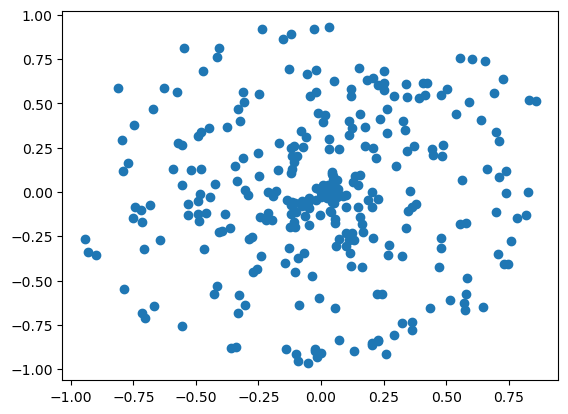

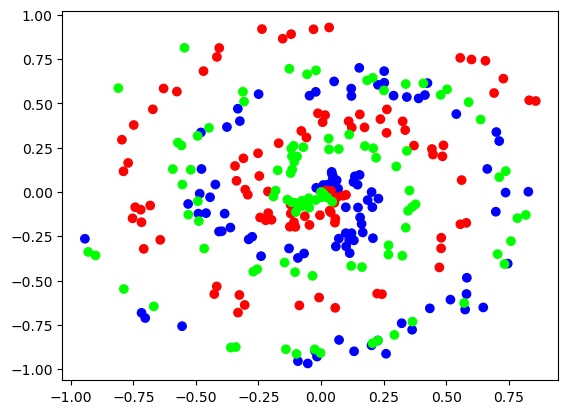

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def create_data(samples, classes):
    X = np.zeros((samples * classes, 2))
    y = np.zeros(samples * classes, dtype="uint8")

    for class_number in range(classes):
        ix = range(samples * class_number, samples * (class_number + 1))
        r = np.linspace(0.0, 1, samples)
        t = np.linspace(class_number * 3, (class_number + 1) * 4, samples) + np.random.randn(samples) * 0.2

        X[ix] = np.c_[r * np.sin(t * 2.5), r * np.cos(t * 2.5)]
        y[ix] = class_number

    return X, y

X, y = create_data(samples = 100, classes = 3)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="brg")
plt.show()

In [ ]:
# Updating the NN with the ReLu activation function
nnfs.init()

X = np.matrix([[1.,2.,3.,2.5], [2.,5.,-1.,2.],[-1.5,2.7,3.3,-.8]]) #Input layer

X, y = create_data(samples = 100, classes= 3)

class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)# randn is a gausian distrubtion that bounces from 0 (multiplies with 0.10 to keep the initialized wheigths around 0)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

class Activation_ReLU:
    def forward (self, inputs):
        self.output = np.maximum(0,inputs)


layer1 = Layer_Dense(2, 5) # Input layer 4 and outputs 5
activation1 = Activation_ReLU()
layer2 = Layer_Dense(5, 2) # Takes the 5 neurons outputs as inputs and outputs 2 neurons
activation2 = Activation_ReLU()

layer1.forward(X)
activation1.forward(layer1.output)
#print(layer1.output)
layer2.forward(layer1.output)
activation2.forward(layer2.output)
#print(layer2.output)
#display(layer1.output, layer2.output)
print(activation1.output)

[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 4.65504505e-04
  4.56846210e-05]
 [0.00000000e+00 5.93469958e-05 0.00000000e+00 2.03573116e-04
  6.10024377e-04]
 ...
 [1.20253474e-01 0.00000000e+00 0.00000000e+00 7.56691992e-02
  0.00000000e+00]
 [1.35745674e-01 0.00000000e+00 3.74826714e-02 5.26372716e-02
  0.00000000e+00]
 [1.07817926e-01 0.00000000e+00 0.00000000e+00 8.72561932e-02
  0.00000000e+00]]


## Softmax

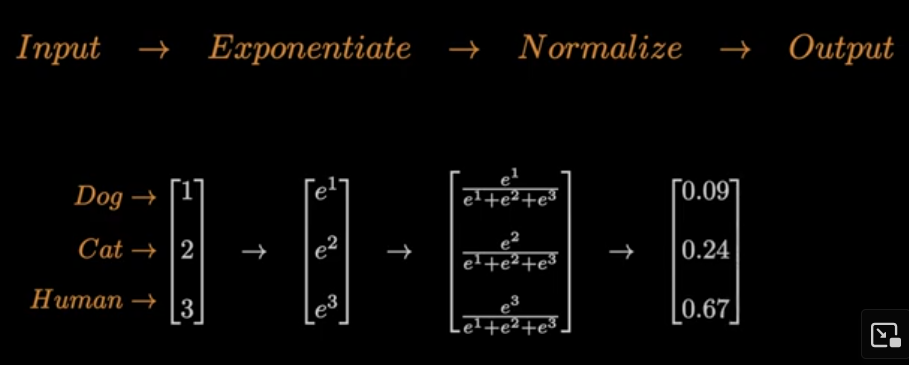

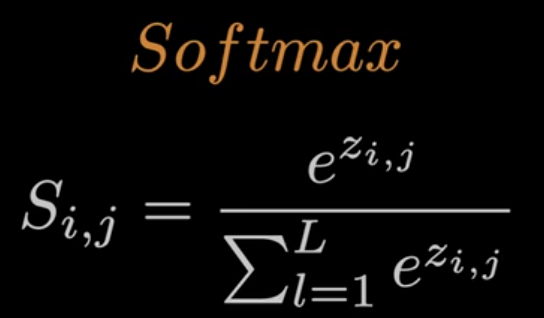

In [ ]:
# Simple demonstration of the Softmax
layer_outputs = [4.8,1.21,2.385]

exp_values = []

for output in layer_outputs:
    exp_values.append(np.exp(output))
print(exp_values)

norm_base = sum(exp_values)
norm_values = []

for value in exp_values:
    norm_values.append(value / norm_base) # normalises the exp values so that they will sum up to 1

print(norm_values)# Also gives the distrubution
print(sum(norm_values))


[np.float64(121.51041751873485), np.float64(3.3534846525490236), np.float64(10.859062664920515)]
[np.float64(0.8952826639572619), np.float64(0.02470830678209937), np.float64(0.0800090292606387)]
0.9999999999999999


In [ ]:
# Simplified version
layer_outputs = np.array([[4.8,1.21,2.385],
                          [8.9,-1.81,.2],
                          [1.41,1.051,.026]])

exp_values = np.exp(layer_outputs)

# print(np.sum(layer_outputs, axis = 1,keepdims = True)) # Axis chooses if it is the coloums or rows that are beeing summed. Axis 1 sumes the rows.

norm_values = exp_values / np.sum(exp_values, axis = 1, keepdims= True)
norm_values

array([[8.95282664e-01, 2.47083068e-02, 8.00090293e-02],
       [9.99811129e-01, 2.23163963e-05, 1.66554348e-04],
       [5.13097164e-01, 3.58333899e-01, 1.28568936e-01]])

In [ ]:
# Updating the NN with the softmax activation function
nnfs.init()


class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)# randn is a gausian distrubtion that bounces from 0 (multiplies with 0.10 to keep the initialized wheigths around 0)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

class Activation_ReLU:
    def forward (self, inputs):
        self.output = np.maximum(0,inputs)

class Activation_Softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis = 1, keepdims=True))
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=1)
        self.output = probabilities


X, y = create_data(samples = 100, classes = 3)

dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(3, 3)
activation2 = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])

[[0.33333334 0.33333334 0.33333334]
 [0.33331734 0.3333183  0.33336434]
 [0.3332888  0.33329153 0.33341965]
 [0.33325943 0.33326396 0.33347666]
 [0.33323312 0.33323926 0.33352762]]


# Loss

In [ ]:
import math

In [ ]:
# e ** x = b, log finds out what x needs to be for it can be equal to b (natural log)
b = 5.2
print(np.log(b))

1.6486586255873816


In [ ]:
softmax_output = [.7,.1,.2]
target_output = [1,0,0] # If the target class is 0

loss = -(math.log(softmax_output[0])*target_output[0] +
         math.log(softmax_output[1])*target_output[1] +
         math.log(softmax_output[2])*target_output[2])

print(loss)
loss = -math.log(softmax_output[0])
print(loss)




0.35667494393873245
0.35667494393873245


In [ ]:
# Updating the NN with the Loss function
nnfs.init()


class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)# randn is a gausian distrubtion that bounces from 0 (multiplies with 0.10 to keep the initialized wheigths around 0)
        self.biases = np.zeros((1, n_neurons))
    def forward(self, inputs):
        self.output = np.dot(inputs,self.weights) + self.biases

class Activation_ReLU:
    def forward (self, inputs):
        self.output = np.maximum(0,inputs)

class Activation_Softmax:
    def forward(self,inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis = 1, keepdims=True))
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=1)
        self.output = probabilities

class Loss:
    def calculate(self, output, y):
        sample_losses = self.forward(output,y)
        data_loss = np.mean(sample_losses)
        return data_loss
    
class Loss_CotegoricalCrossentropy(Loss):
    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)
        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true] # One hot encoded vectors
        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped * y_true, axis = 1) # Arrray of one hot encoded vectors
        
        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

# Creating the layers and feed forward the data
X, y = create_data(samples = 100, classes = 3)

dense1 = Layer_Dense(2,3)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(3, 3)
activation2 = Activation_Softmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])

# Loss: 
loss_function = Loss_CotegoricalCrossentropy()
loss = loss_function.calculate(activation2.output, y)

# Accuracy: 
predictions = np.argmax(activation2.output, axis = 1)
accuracy = np.mean(predictions == y)
# Printing the loss and acc
print("Loss:", loss ,"\n Accuracy:", accuracy)




[[0.33333334 0.33333334 0.33333334]
 [0.33331734 0.3333183  0.33336434]
 [0.3332888  0.33329153 0.33341965]
 [0.33325943 0.33326396 0.33347666]
 [0.33323312 0.33323926 0.33352762]]
Loss: 1.0985672 
 Accuracy: 0.34
